# Exploratory ViennaRNA folding of human-mouse CURIA pairs

**Goal.** Inspect whether explicit ViennaRNA secondary-structure predictions show *interpretable* agreement between selected human-mouse CURIA pairs. Two groups are analysed:

1. the three **Figure-5 short-ncRNA** case studies (SNORD57 / RNU6-7 / vault RNA), using the exact reference and predicted-query intervals already shown in Fig. 5;
2. **MALAT1 recurrent cores** taken from the accepted CURIA island-match rows.

For every pair we fold both sequences, **align the nucleotides (affine-gap Smith-Waterman) and map both base-pair-probability matrices (BPPMs) into shared alignment coordinates**, then compare structures visually (aligned BPPMs, an overlay contact map, mirrored MFE arc diagrams, and per-position pairing probability). For the MALAT1 cores we also sweep the interval boundaries.

> **Caveats (read first).**
> - This notebook is **exploratory only**. It does **not** modify the manuscript or the production pipeline.
> - Structures are compared in **sequence-alignment coordinates** so that small insertions/deletions do not spuriously misregister the two matrices. The overlap numbers (shared pairs, Jaccard, weighted Jaccard/overlap) are **ad-hoc descriptive values for visual triage, not validated structural metrics**.
> - Nothing here claims that BPPM similarity validates CURIA, RNA function, or evolutionary orthology.
> - Selection criteria and coordinates are **pre-registered** in \`selected_examples.tsv\` *before* any fold is computed (see below). Examples are **not** cherry-picked after seeing the folds.
> - Sequences are recovered from the existing Fig-5 inputs / CURIA result tables via the same 2bit accessors the pipeline uses; loci are **not** re-searched by gene name.

In [1]:
import importlib
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import scipy
import matplotlib
import matplotlib.pyplot as plt
import RNA

# repo root + local helper module
REPO = Path.cwd()
while not (REPO / "input_data" / "2bit").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
HELP_DIR = REPO / "analysis" / "vienna_structure_examples"
sys.path.insert(0, str(HELP_DIR))
import vienna_helpers as vh
importlib.reload(vh)

OUT = HELP_DIR
PLOTS = OUT / "plots"
PLOTS.mkdir(parents=True, exist_ok=True)

import pyrion
VERSIONS = {
    "ViennaRNA (RNA)": RNA.__version__,
    "numpy": np.__version__,
    "scipy": scipy.__version__,
    "matplotlib": matplotlib.__version__,
    "pandas": pd.__version__,
    "pyrion": getattr(pyrion, "__version__", "?"),
    "python": sys.version.split()[0],
}
print("REPO      :", REPO)
print("output dir:", OUT)
for k, v in VERSIONS.items():
    print(f"{k:18s}: {v}")

REPO      : /Users/Bogdan.Kirilenko/Developer/CURIA_pipeline
output dir: /Users/Bogdan.Kirilenko/Developer/CURIA_pipeline/analysis/vienna_structure_examples
ViennaRNA (RNA)   : 2.7.2
numpy             : 2.4.3
scipy             : 1.17.1
matplotlib        : 3.10.9
pandas            : 3.0.1
pyrion            : 0.4.0
python            : 3.14.2


## Pre-registered selection (before folding)

Selection criteria and coordinates are fixed in \`selected_examples.tsv\` **before** any ViennaRNA result is computed.

**Group 1 - Figure-5 short ncRNAs.** The three loci shown in Fig. 5, with the *exact* reference and predicted-query intervals from \`analysis/embedding_vs_sequence/case_studies_fig5.tsv\`: SNORD57 (chain 7), RNU6-7 (chain 1), vault RNA / ENSG00000199990 (chain 57). No alternative loci are searched by gene name.

**Group 2 - MALAT1 recurrent cores.** MALAT1 = ENSG00000251562. The accepted (assigned) CURIA island-match rows for MALAT1 in \`analysis/embedding_vs_sequence/island_pair_metrics_mouse.tsv\` are R2, R3, R4, R5 (four cores). Selection covers the requested spread:

| core | genomic role | why chosen |
|------|--------------|------------|
| **R5** | highest hg38 coord -> nearest MALAT1 3' structured region (+ strand) | strong core, lowest `diag_mmd` = 0.0125 |
| **R4** | mid-locus | strong embedding core, **highest** nucleotide identity (SW aligned ident 0.857) |
| **R3** | mid-locus | moderate match (`diag_mmd` = 0.0458) |
| **R2** | 5'-proximal | **lowest** sequence similarity (SW aligned ident 0.601, edit identity 0.292) |

Mouse counterparts are the actual accepted CURIA match rows (query islands Q0/Q3/Q4/Q6 on chr19). Human MALAT1 is `+` strand; mouse Malat1 is `-` strand, so the mouse sense RNA is the reverse complement of the forward genomic fetch (the pipeline scores both orientations and keeps the best).

In [2]:
# --- load the pre-registered selection + the existing CURIA metric tables ---
sel = pd.read_csv(OUT / "selected_examples.tsv", sep="\t")

EVS = REPO / "analysis" / "embedding_vs_sequence"
fig5 = pd.read_csv(EVS / "case_studies_fig5.tsv", sep="\t")
isl = pd.read_csv(EVS / "island_pair_metrics_mouse.tsv", sep="\t")
isl_aln = pd.read_csv(REPO / "preprint_results/hg38_vs_mm39/island_alignment_results.tsv", sep="\t")

MALAT1_ID = "ENSG00000251562"   # gene_id in island tables is 'U_ENSG00000251562.13'

# metrics lookup keyed by the pre-registered label
METRICS = {}
for r in fig5.itertuples(index=False):
    METRICS[r.fig5_label] = dict(
        table_identity=round(float(r.ident_levenshtein), 4),
        table_sw_norm=round(float(r.sw_norm), 4),
        table_sw_aligned=round(float(r.sw_aligned_ident), 4),
        table_mmd=round(float(r.mmd), 4),
        aligned_len=int(min(r.ref_len_spliced, r.query_len)),
        emb_sw="n/a (short-ncRNA analysis)",
    )

MAL = isl[isl.gene_id.str.contains(MALAT1_ID) & (isl.assigned == True)].copy()
ALN = isl_aln[isl_aln.gene_id.str.contains(MALAT1_ID)].copy()
aln_by_isl = {r.ref_island: int(r.chain1_ref_to - r.chain1_ref_from) for r in ALN.itertuples(index=False)}
for r in MAL.itertuples(index=False):
    label = f"MALAT1.{r.ref_island}"
    METRICS[label] = dict(
        table_identity=round(float(r.ident_levenshtein), 4),   # nucleotide identity
        table_sw_norm=round(float(r.sw_norm), 4),              # normalized nucleotide SW
        table_sw_aligned=round(float(r.sw_aligned_ident), 4),
        table_mmd=round(float(r.diag_mmd), 4),                 # embedding MMD distance
        aligned_len=aln_by_isl.get(r.ref_island, "n/a"),       # chain1 aligned span
        emb_sw=round(float(r.emb_sw), 3),                      # embedding-SW score
    )

print("MALAT1 assigned island rows found:", len(MAL))
print("pre-registered pairs:", len(sel))
print("metrics resolved for :", sorted(METRICS))
sel[["group", "label", "ref_chrom", "ref_start", "ref_end", "query_chrom", "query_start", "query_end", "query_strand", "selection_reason"]]

MALAT1 assigned island rows found: 4
pre-registered pairs: 7
metrics resolved for : ['MALAT1.R2', 'MALAT1.R3', 'MALAT1.R4', 'MALAT1.R5', 'RNU6-7.1', 'SNORD57.7', 'VTRNA(vaultRNA).57']


,group,label,ref_chrom,ref_start,ref_end,query_chrom,query_start,query_end,query_strand,selection_reason
0,fig5_short,SNORD57.7,chr20,2656938,2657010,chr2,130119932,130120004,+,Figure-5 short-ncRNA case study (exact Fig.5 i...
1,fig5_short,RNU6-7.1,chr14,32202044,32202151,chr12,52650566,52650673,+,Figure-5 short-ncRNA case study (exact Fig.5 i...
2,fig5_short,VTRNA(vaultRNA).57,chr5,140711274,140711373,chr18,36934960,36935061,+,Figure-5 short-ncRNA case study (exact Fig.5 i...
3,malat1_core,MALAT1.R5,chr11,65505924,65506332,chr19,5845844,5846132,-,strong core (lowest diag_mmd=0.0125) nearest M...
4,malat1_core,MALAT1.R4,chr11,65504284,65504452,chr19,5847470,5847918,-,strong embedding core (diag_mmd=0.0173) with h...
5,malat1_core,MALAT1.R3,chr11,65503364,65503732,chr19,5848510,5848678,-,moderate core (diag_mmd=0.0458)
6,malat1_core,MALAT1.R2,chr11,65501924,65502172,chr19,5849710,5850518,-,lower-sequence-similarity core (sw_aligned_ide...


## Methods

**Sequences.** Recovered from the same 2bit genomes and accessors the pipeline uses: `pyrion.TwoBitAccessor` on `hg38.2bit` (reference) and `AliasedTwoBitAccessor` on `mm39.2bit` (query). Coordinates are the pre-registered BED intervals; sequences are taken on the gene's strand (reverse-complemented for the `-`-strand mouse Malat1).

**Folding (ViennaRNA).** For each sequence: global partition-function BPPM `fc.bpp()`, MFE structure `fc.mfe()`, ensemble free energy (EFE) `fc.pf()`, ensemble diversity `fc.mean_bp_distance()`, and per-position pairing probability. For MALAT1 windows we additionally compute **RNAplfold** local pairing (`RNA.pfl_fold`, W<=150, L<=100 clamped to length). Default model (37 C, Turner 2004).

**Alignment-aware mapping.** Human and mouse nucleotides are aligned with an affine-gap Smith-Waterman local aligner (CURIA-wired recurrence from `seqmetrics._sw_affine`, re-implemented to return the gapped column path; encoding via `pyrion.utils.encode_nucleotides`). Both BPPMs are mapped into the shared gapped alignment coordinate system. Fig-5 short ncRNAs are similar-length and folded whole; MALAT1 cores are folded on length-matched windows (aligned span, +/-20, +/-40 nt) - never the raw unequal island intervals.

**Overlap metrics (all EXPLORATORY descriptive values, NOT validated structure-similarity scores).**
- *Column-exact*: shared high-probability pairs (both P>=0.1 at the same aligned (i,j)); weighted Jaccard `sum min(H,M)/sum max(H,M)`; weighted overlap `sum min(H,M)/min(sum H, sum M)`.
- *Tolerance-aware*: the column-exact count is brittle to small pairing-register shifts, so we also match pairs one-to-one by **maximum-weight bipartite matching** (`scipy.optimize.linear_sum_assignment`), where a human pair (i,j) and mouse pair (k,l) are compatible iff `|i-k|<=tol` and `|j-l|<=tol`, with match weight = min(P_human, P_mouse). We report the tolerant shared-pair count and tolerant weighted overlap (sum of matched weights / min of the two pair-probability masses) at **tol = 2 and tol = 3** alignment columns. Both the column-exact and tolerant values are kept so the exact-vs-tolerant distinction stays visible.

**Reported per pair.** sequence lengths; existing CURIA table metrics; aligned columns + %id; MFE; ensemble diversity; column-exact shared count + weighted Jaccard; tolerant +/-2 and +/-3 shared count + weighted overlap.

In [3]:
# --- Fig-5: fold + align + map (similar lengths, directly comparable).
# --- MALAT1: only ALIGN the full intervals here to locate the homologous span;
#     folding is done later on MATCHED windows (the raw intervals differ drastically
#     in length, so folding them whole would confound the comparison).
importlib.reload(vh)
PMIN = 0.1   # probability cutoff for overlays + thresholded-pair descriptors
FOLDS = {}
fig5_rows = []
for r in sel.itertuples(index=False):
    rs = vh.fetch("ref", r.ref_chrom, r.ref_start, r.ref_end, r.ref_strand)
    qs = vh.fetch("query", r.query_chrom, r.query_start, r.query_end, r.query_strand)
    extra = METRICS.get(r.label, {})
    meta = dict(label=r.label, group=r.group, chain_or_island=r.chain_or_island)
    if r.group == "fig5_short":
        fr = vh.fold(rs); fq = vh.fold(qs)
        aln = vh.align_sequences(rs, qs)
        Mr = vh.map_bppm(fr["bppm"], aln["ref_to_col"], aln["L"])
        Mq = vh.map_bppm(fq["bppm"], aln["query_to_col"], aln["L"])
        om = vh.overlap_metrics(Mr, Mq, PMIN)   # column-exact + tolerant (+/-2, +/-3)
        FOLDS[r.label] = dict(meta=meta, fr=fr, fq=fq, aln=aln, Mr=Mr, Mq=Mq, extra=extra, rs=rs, qs=qs)
        fig5_rows.append(dict(
            group=r.group, label=r.label, human_gene=r.human_gene,
            ref_len=fr["length"], query_len=fq["length"],
            seq_identity_table=extra.get("table_identity"), sw_norm_table=extra.get("table_sw_norm"),
            sw_aligned_ident_table=extra.get("table_sw_aligned"), curia_aligned_len=extra.get("aligned_len"),
            mmd_or_diagmmd=extra.get("table_mmd"), embedding_sw=extra.get("emb_sw"),
            ref_mfe=round(fr["mfe"], 2), query_mfe=round(fq["mfe"], 2),
            ref_ens_div=round(fr["ensemble_diversity"], 2), query_ens_div=round(fq["ensemble_diversity"], 2),
            aln_cols=aln["aln_cols"], aln_pct_id=round(aln["aln_ident"] * 100, 1),
            n_shared_exact=om["n_shared"], weighted_jaccard=round(om["weighted_jaccard"], 3),
            weighted_overlap=round(om["weighted_overlap"], 3),
            n_shared_tol2=om["n_shared_tol2"], wov_tol2=round(om["wov_tol2"], 3),
            n_shared_tol3=om["n_shared_tol3"], wov_tol3=round(om["wov_tol3"], 3)))
    else:  # MALAT1: align-only to find the homologous span
        aln = vh.align_sequences(rs, qs)
        span = vh.aligned_offsets(aln)
        FOLDS[r.label] = dict(meta=meta, rs=rs, qs=qs, aln_full=aln, span=span, extra=extra, row=r)

summary_fig5 = pd.DataFrame(fig5_rows)
print("Fig-5 folded + aligned; MALAT1 aligned-only (windows folded below).")
for lbl in ["MALAT1.R5", "MALAT1.R4", "MALAT1.R3", "MALAT1.R2"]:
    rlo, rhi, qlo, qhi = FOLDS[lbl]["span"]; d = FOLDS[lbl]
    print(f"  {lbl}: full ref={len(d['rs'])} full query={len(d['qs'])} -> homologous span ref[{rlo}:{rhi}]={rhi-rlo}nt, query[{qlo}:{qhi}]={qhi-qlo}nt")
summary_fig5

Fig-5 folded + aligned; MALAT1 aligned-only (windows folded below).
  MALAT1.R5: full ref=408 full query=288 -> homologous span ref[58:383]=325nt, query[0:285]=285nt
  MALAT1.R4: full ref=168 full query=448 -> homologous span ref[0:164]=164nt, query[133:293]=160nt
  MALAT1.R3: full ref=368 full query=168 -> homologous span ref[1:178]=177nt, query[3:166]=163nt
  MALAT1.R2: full ref=248 full query=808 -> homologous span ref[0:242]=242nt, query[517:760]=243nt


,group,label,human_gene,ref_len,query_len,seq_identity_table,sw_norm_table,sw_aligned_ident_table,curia_aligned_len,mmd_or_diagmmd,...,query_ens_div,aln_cols,aln_pct_id,n_shared_exact,weighted_jaccard,weighted_overlap,n_shared_tol2,wov_tol2,n_shared_tol3,wov_tol3
0,fig5_short,SNORD57.7,SNORD57,72,72,0.7361,0.6667,0.7971,72,0.0000,...,16.59,69,79.7,8,0.096,0.180,22,0.442,24,0.492
1,fig5_short,RNU6-7.1,RNU6-7,107,107,0.9252,0.9626,1.0000,107,0.0000,...,7.98,103,100.0,34,0.937,0.997,34,1.000,34,1.000
2,fig5_short,VTRNA(vaultRNA).57,VTRNA(vaultRNA),99,101,0.5941,0.3485,0.6316,99,0.1366,...,10.81,83,72.3,0,0.000,0.000,0,0.000,3,0.108


## Group 1 - Figure-5 short ncRNAs

For each pair: reference BPPM, query BPPM, rescaled 128x128 BPPMs + absolute difference, and the two MFE structures as arc diagrams, plus a metrics panel. Figures are saved to \`plots/\`.

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


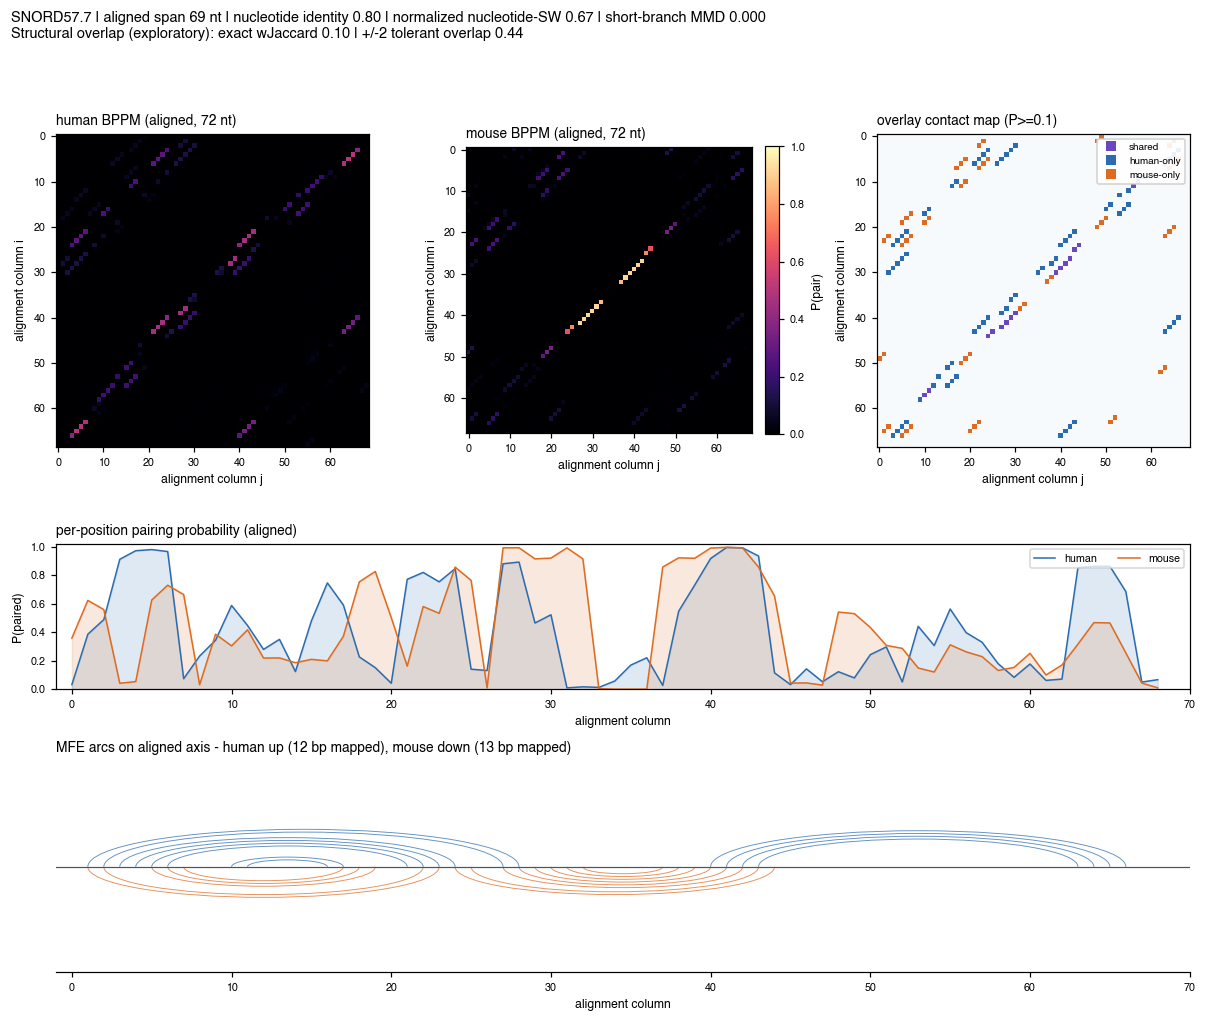

saved: fig5_SNORD57_7.png / .pdf


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


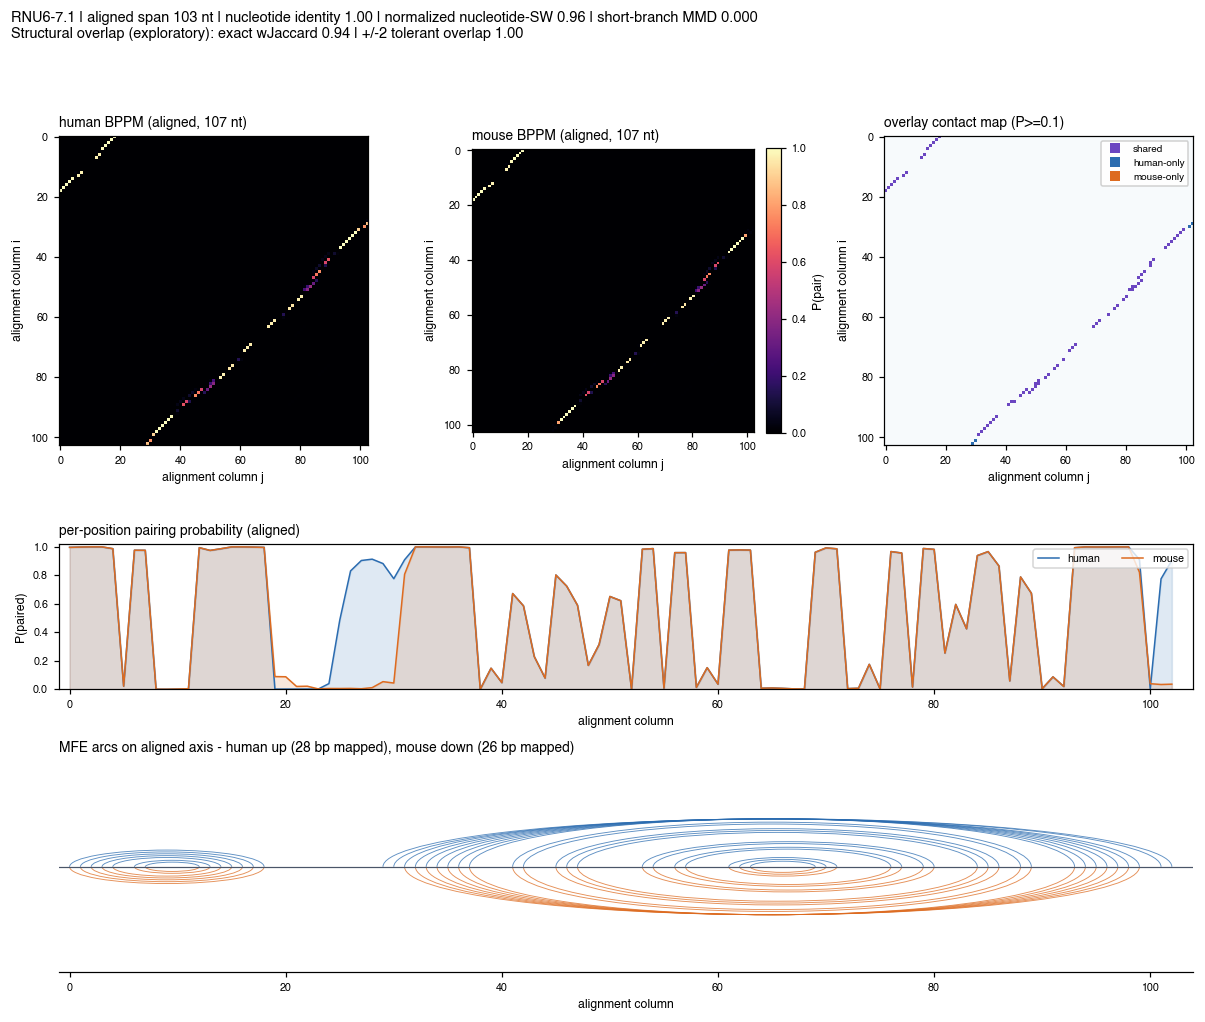

saved: fig5_RNU6-7_1.png / .pdf


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


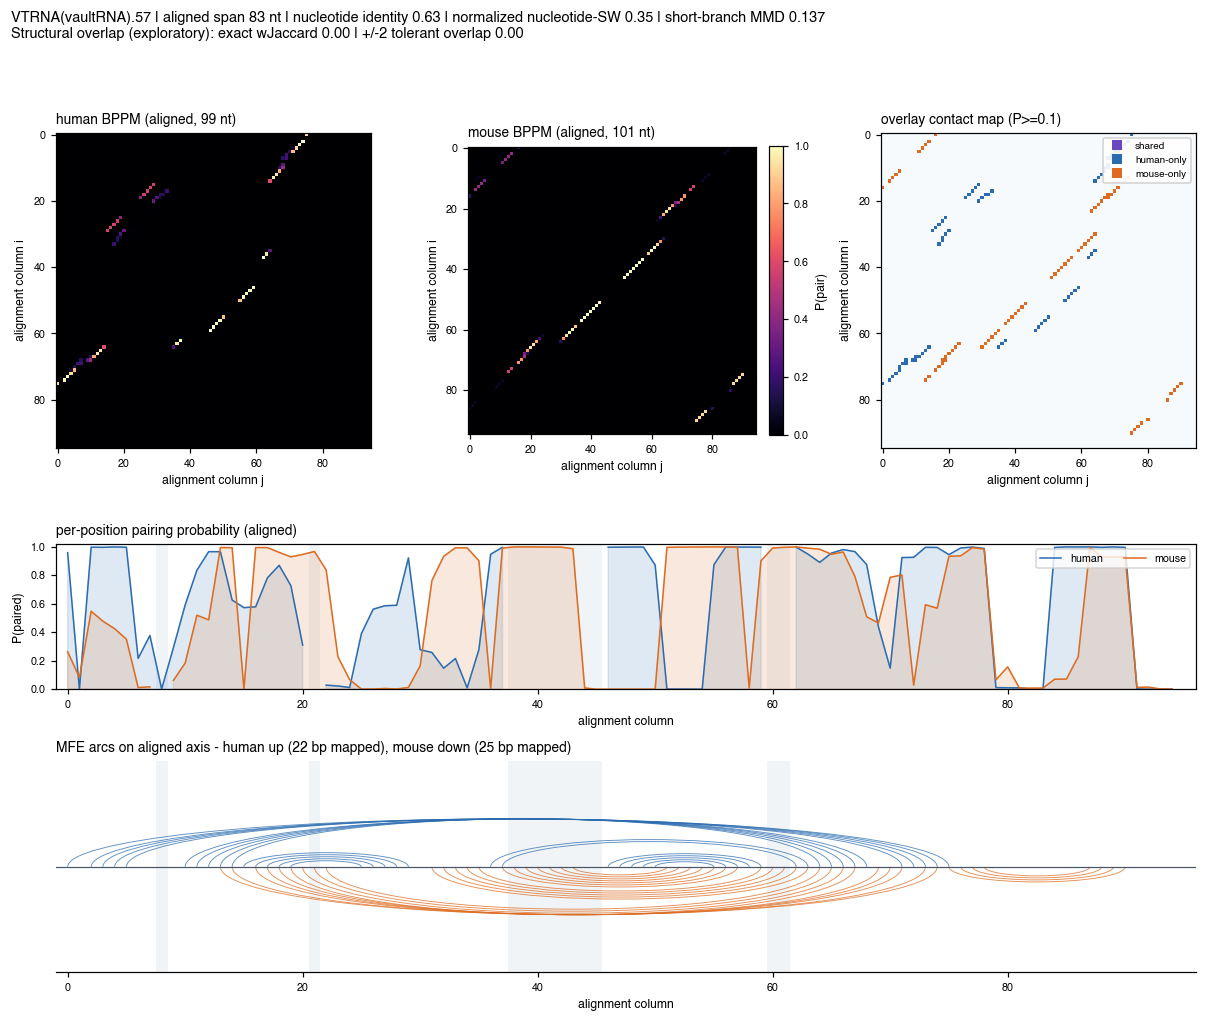

saved: fig5_VTRNA_vaultRNA_57.png / .pdf


In [4]:
from IPython.display import display
importlib.reload(vh)

for label in ["SNORD57.7", "RNU6-7.1", "VTRNA(vaultRNA).57"]:
    d = FOLDS[label]
    stem = PLOTS / ("fig5_" + label.replace("(", "_").replace(")", "").replace("/", "_").replace(".", "_"))
    fig = vh.plot_pair_aligned(d["meta"], d["fr"], d["fq"], d["aln"], d["Mr"], d["Mq"], d["extra"], stem, pmin=PMIN)
    display(fig)
    plt.close(fig)
    print("saved:", stem.name + ".png / .pdf")

## Group 2 - MALAT1 recurrent cores (matched-window analysis)

**Why the previous version was confounded.** The raw CURIA island intervals for the human and mouse cores differ drastically in length (e.g. R4 168 vs 448 nt; R2 248 vs 808 nt). Folding the *whole* unequal intervals lets long unaligned query flanks reroute the global fold of the aligned region, and base pairs that involve unaligned residues are then silently discarded when results are mapped into alignment coordinates. The earlier full-interval MALAT1 overlap numbers should therefore be treated as **invalid**.

**Corrected procedure.**
1. Align the full human/mouse intervals only to **locate the homologous span** in each species (done in the previous cell).
2. Extract **comparable windows** around that span: `core` (aligned span only), `+/-20` and `+/-40` nt symmetric genomic flanks (fetched from the genome, strand-preserving; the raw unequal intervals are never folded).
3. For each window, re-align the two windows and fold with **both**: (a) the global ViennaRNA partition function; (b) **RNAplfold** local pairing probabilities (documented window size W/L). Map both into alignment coordinates and visualise as before.
4. Report actual window lengths and alignment coverage for every comparison.
5. Treat a structural pattern as potentially interpretable **only if it is qualitatively stable across `core`, `+/-20`, and `+/-40`** and consistent between the global and local methods; flag large boundary-dependent changes as **inconclusive**.

In [5]:
# --- build matched windows for every MALAT1 core: fold (global pf + RNAplfold) ---
importlib.reload(vh)
LEVELS = [("core", 0), ("+/-20", 20), ("+/-40", 40)]
PLF_W, PLF_L = 150, 100   # documented RNAplfold sliding-window / max-span (clamped to len)
MAL_LABELS = ["MALAT1.R5", "MALAT1.R4", "MALAT1.R3", "MALAT1.R2"]

def genomic_window(row, span, flank):
    """Genomic window = homologous span +/- flank, in each species' own coords."""
    rlo, rhi, qlo, qhi = span
    rg0, rg1 = row.ref_start + rlo, row.ref_start + rhi           # ref is '+' strand
    if row.query_strand == "-":                                    # sense offset -> genomic
        qg0, qg1 = row.query_end - qhi, row.query_end - qlo
    else:
        qg0, qg1 = row.query_start + qlo, row.query_start + qhi
    rs = vh.fetch("ref", row.ref_chrom, rg0 - flank, rg1 + flank, row.ref_strand)
    qs = vh.fetch("query", row.query_chrom, qg0 - flank, qg1 + flank, row.query_strand)
    return rs, qs

WIN = {}          # label -> level -> dict(aln, fr, fq, Mr_g, Mq_g, Mr_p, Mq_p, mg, mp, ...)
malat_rows = []
for label in MAL_LABELS:
    d = FOLDS[label]; row = d["row"]; span = d["span"]
    WIN[label] = {}
    for lvname, f in LEVELS:
        rs, qs = genomic_window(row, span, f)
        aln = vh.align_sequences(rs, qs)
        L = aln["L"]
        fr, fq = vh.fold(rs), vh.fold(qs)                          # global partition function
        Mr_g = vh.map_bppm(fr["bppm"], aln["ref_to_col"], L)
        Mq_g = vh.map_bppm(fq["bppm"], aln["query_to_col"], L)
        mg = vh.overlap_metrics(Mr_g, Mq_g, PMIN)                   # exact + tolerant
        pr, pq = vh.fold_plfold(rs, PLF_W, PLF_L), vh.fold_plfold(qs, PLF_W, PLF_L)   # local
        Mr_p = vh.map_bppm(pr["bppm"], aln["ref_to_col"], L)
        Mq_p = vh.map_bppm(pq["bppm"], aln["query_to_col"], L)
        mp = vh.overlap_metrics(Mr_p, Mq_p, PMIN)
        WIN[label][lvname] = dict(aln=aln, fr=fr, fq=fq, Mr_g=Mr_g, Mq_g=Mq_g,
                                  Mr_p=Mr_p, Mq_p=Mq_p, mg=mg, mp=mp, rs=rs, qs=qs)
        for method, mm, W, Lp in [("global", mg, np.nan, np.nan), ("plfold", mp, pr["plfold_W"], pr["plfold_L"])]:
            malat_rows.append(dict(
                label=label, level=lvname, flank=f, method=method,
                ref_len=fr["length"], query_len=fq["length"], aln_cols=aln["aln_cols"],
                aln_pct_id=round(aln["aln_ident"] * 100, 1),
                cov_ref=round(aln["aln_cols"] / fr["length"], 3),
                cov_query=round(aln["aln_cols"] / fq["length"], 3),
                plfold_W=W, plfold_L=Lp,
                n_shared_exact=mm["n_shared"], weighted_jaccard=round(mm["weighted_jaccard"], 3),
                weighted_overlap=round(mm["weighted_overlap"], 3),
                n_shared_tol2=mm["n_shared_tol2"], wov_tol2=round(mm["wov_tol2"], 3),
                n_shared_tol3=mm["n_shared_tol3"], wov_tol3=round(mm["wov_tol3"], 3)))
malat_windows = pd.DataFrame(malat_rows)
print(f"folded {len(MAL_LABELS)} cores x {len(LEVELS)} windows x 2 methods (RNAplfold W<={PLF_W}, L<={PLF_L})")
malat_windows

folded 4 cores x 3 windows x 2 methods (RNAplfold W<=150, L<=100)


,label,level,flank,method,ref_len,query_len,aln_cols,aln_pct_id,cov_ref,cov_query,plfold_W,plfold_L,n_shared_exact,weighted_jaccard,weighted_overlap,n_shared_tol2,wov_tol2,n_shared_tol3,wov_tol3
0,MALAT1.R5,core,0,global,325,285,285,83.5,0.877,1.000,NaN,NaN,41,0.187,0.332,44,0.373,49,0.394
1,MALAT1.R5,core,0,plfold,325,285,285,83.5,0.877,1.000,150.0,100.0,62,0.263,0.449,84,0.542,87,0.549
2,MALAT1.R5,+/-20,20,global,365,325,316,83.2,0.866,0.972,NaN,NaN,70,0.231,0.397,73,0.457,73,0.457
3,MALAT1.R5,+/-20,20,plfold,365,325,316,83.2,0.866,0.972,150.0,100.0,60,0.228,0.396,78,0.483,81,0.488
4,MALAT1.R5,+/-40,40,global,405,365,362,82.9,0.894,0.992,NaN,NaN,71,0.193,0.345,83,0.429,87,0.441
5,MALAT1.R5,+/-40,40,plfold,405,365,362,82.9,0.894,0.992,150.0,100.0,65,0.216,0.386,82,0.475,89,0.488
6,MALAT1.R4,core,0,global,164,160,156,93.6,0.951,0.975,NaN,NaN,0,0.016,0.032,0,0.000,6,0.035
7,MALAT1.R4,core,0,plfold,164,160,156,93.6,0.951,0.975,150.0,100.0,28,0.199,0.344,36,0.408,52,0.610
8,MALAT1.R4,+/-20,20,global,204,200,190,91.1,0.931,0.950,NaN,NaN,23,0.067,0.131,30,0.172,42,0.207
9,MALAT1.R4,+/-20,20,plfold,204,200,190,91.1,0.931,0.950,150.0,100.0,42,0.175,0.299,65,0.452,80,0.549


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


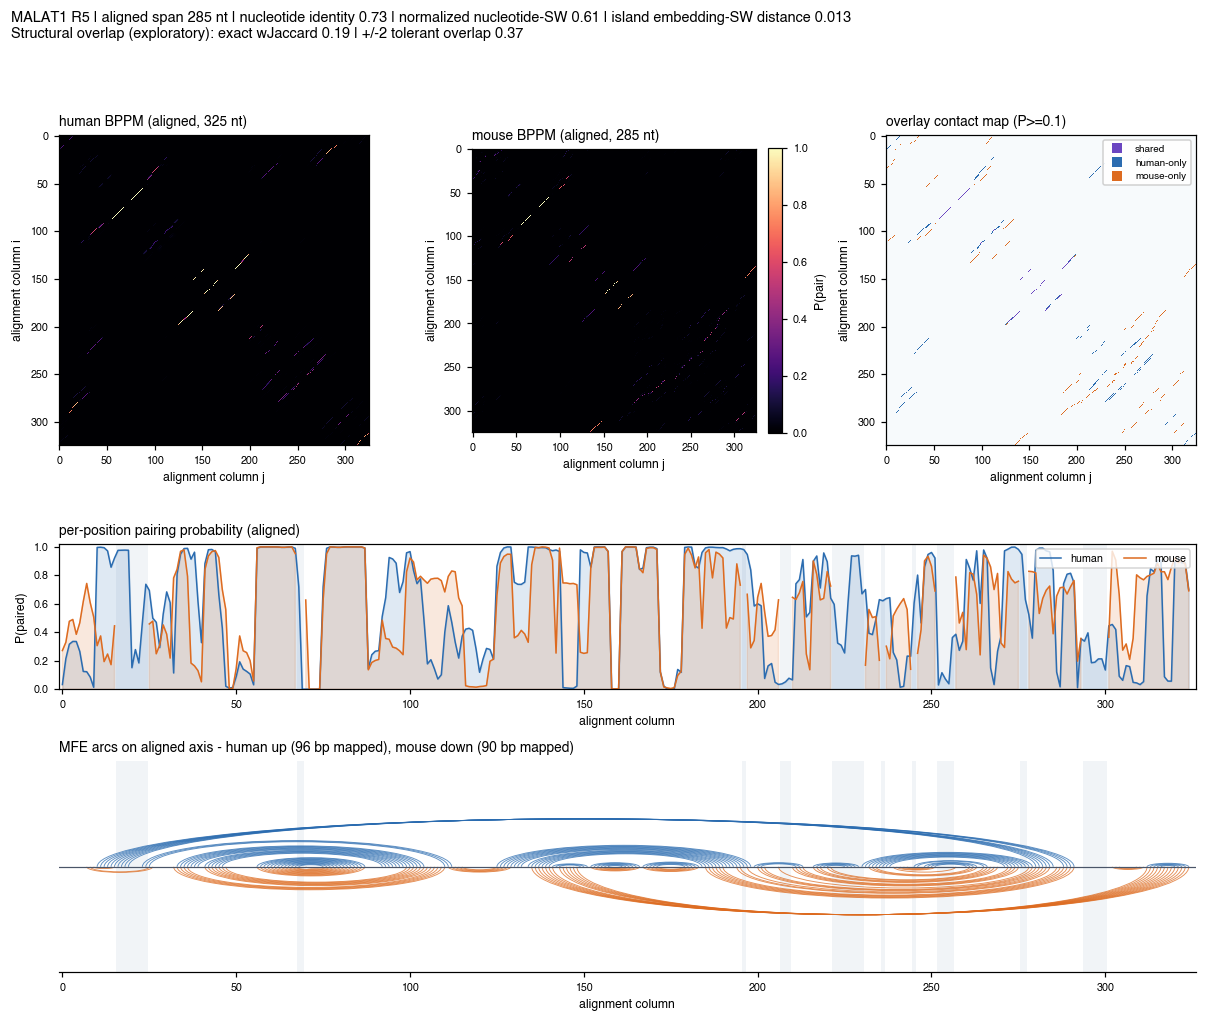

saved: malat1_MALAT1_R5_coreWindow.png / .pdf


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


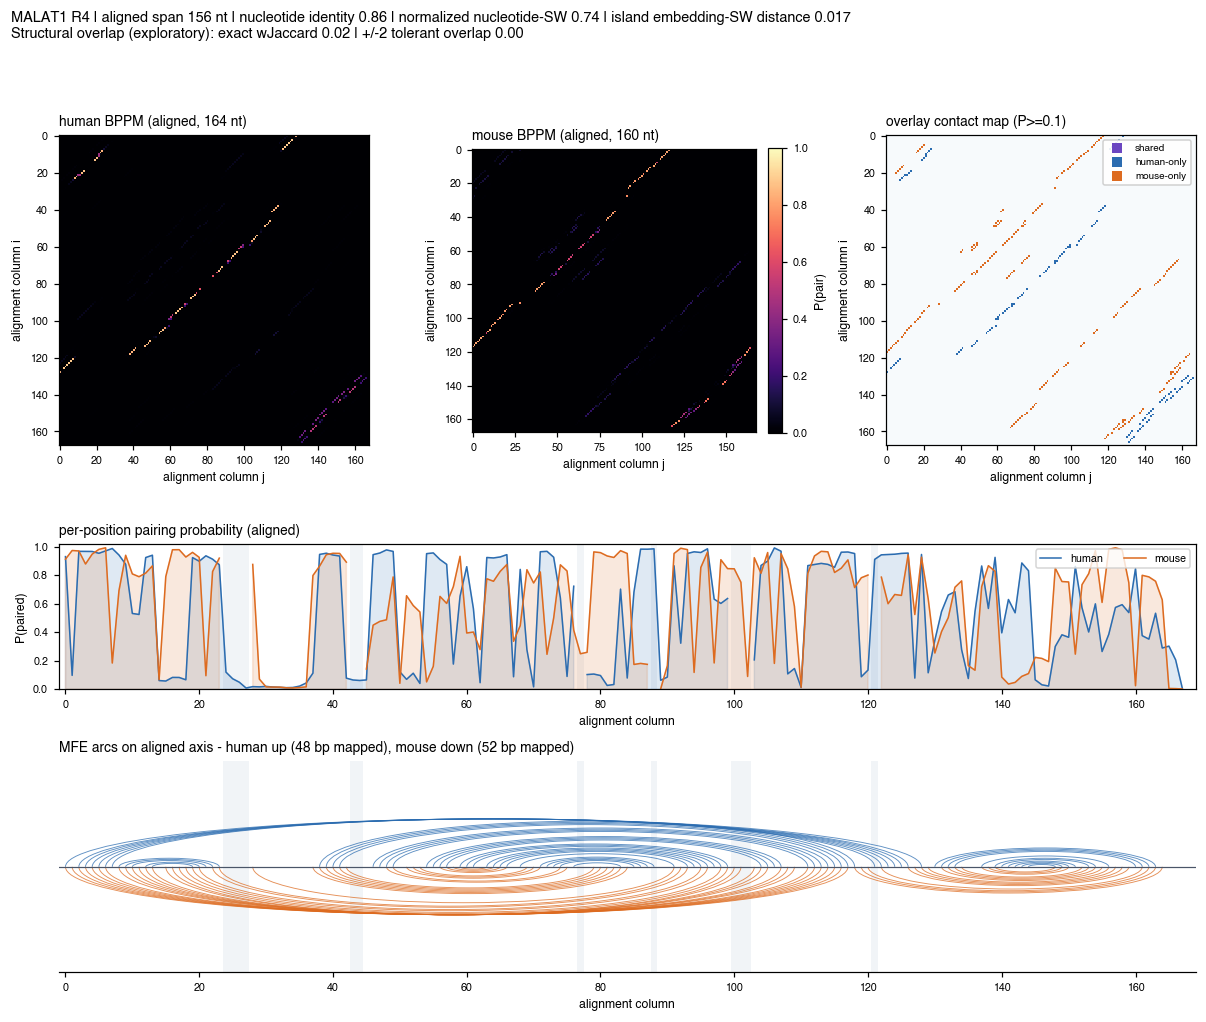

saved: malat1_MALAT1_R4_coreWindow.png / .pdf


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


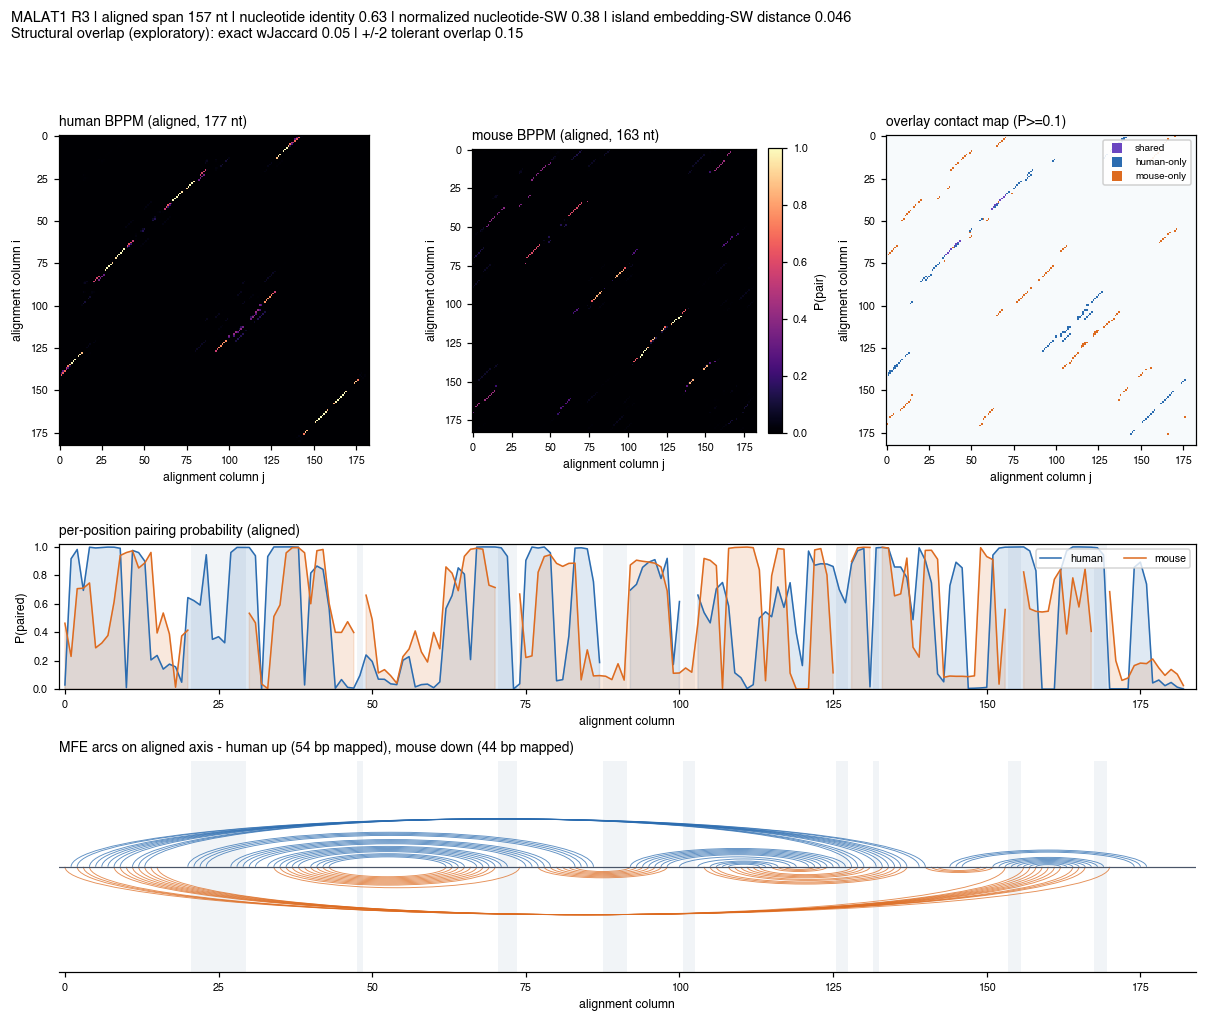

saved: malat1_MALAT1_R3_coreWindow.png / .pdf


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


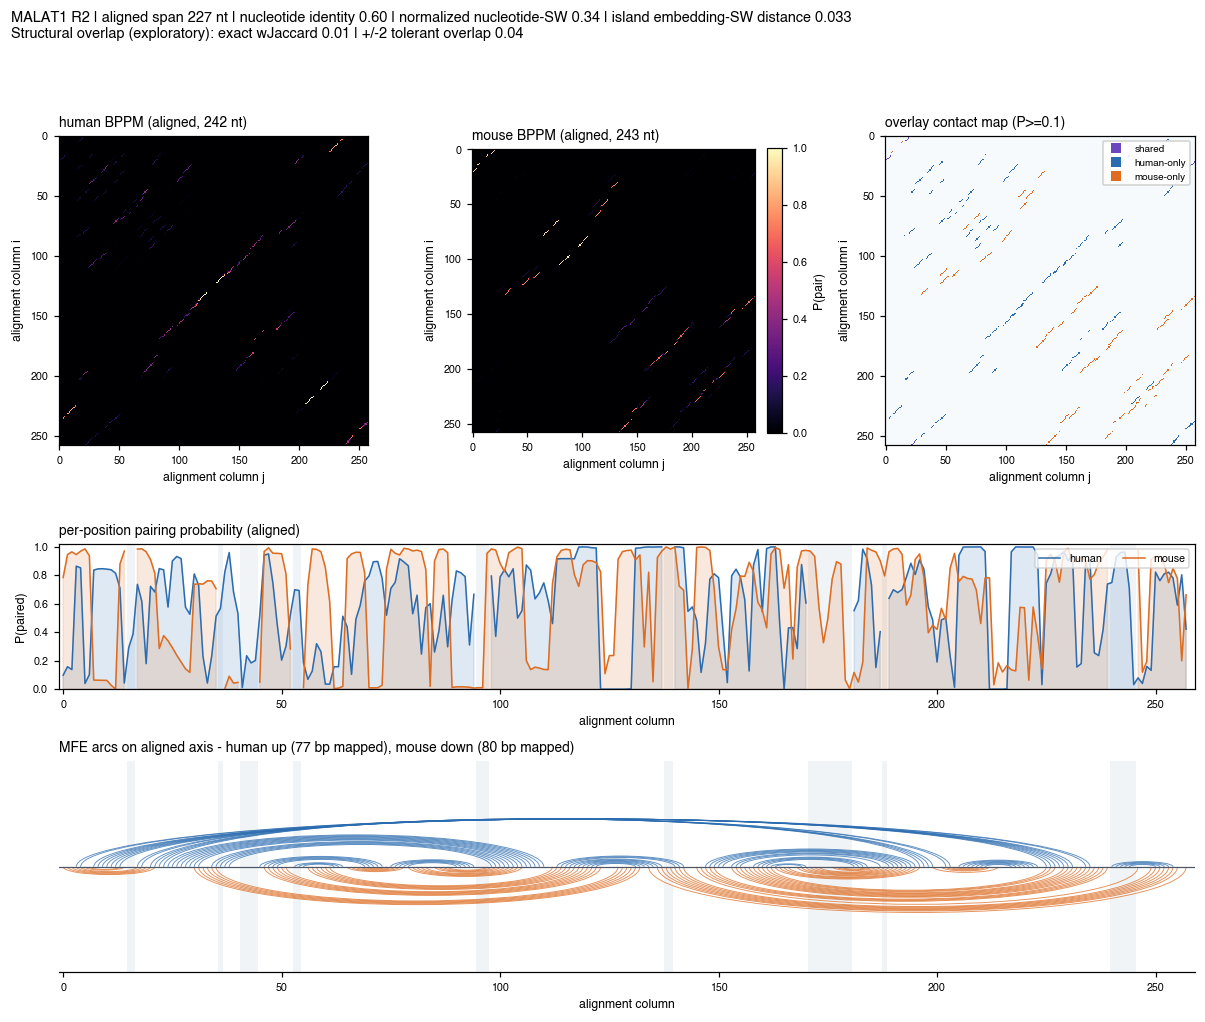

saved: malat1_MALAT1_R2_coreWindow.png / .pdf


In [6]:
# --- detailed alignment-aware figure per core, on the CORE-ONLY matched window ---
# (global partition function; comparable human/mouse window lengths, unlike before)
for label in MAL_LABELS:
    w = WIN[label]["core"]
    stem = PLOTS / ("malat1_" + label.replace(".", "_") + "_coreWindow")
    fig = vh.plot_pair_aligned(FOLDS[label]["meta"], w["fr"], w["fq"], w["aln"],
                               w["Mr_g"], w["Mq_g"], FOLDS[label]["extra"], stem, pmin=PMIN)
    display(fig)
    plt.close(fig)
    print("saved:", stem.name + ".png / .pdf")

## MALAT1 window stability & global-vs-local structure (diagnostic)

For each core we overlay the human/mouse probable pairs (P>=0.1) in alignment coordinates across the three matched windows (`core`, `+/-20`, `+/-40`) with shared pairs as dots plus a mirrored MFE arc overlay. These galleries are **diagnostics only** - they stay under `analysis/vienna_structure_examples/plots/` and are summarized (not shown) in the manuscript-facing PDF by the MALAT1 boundary-stability table.

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


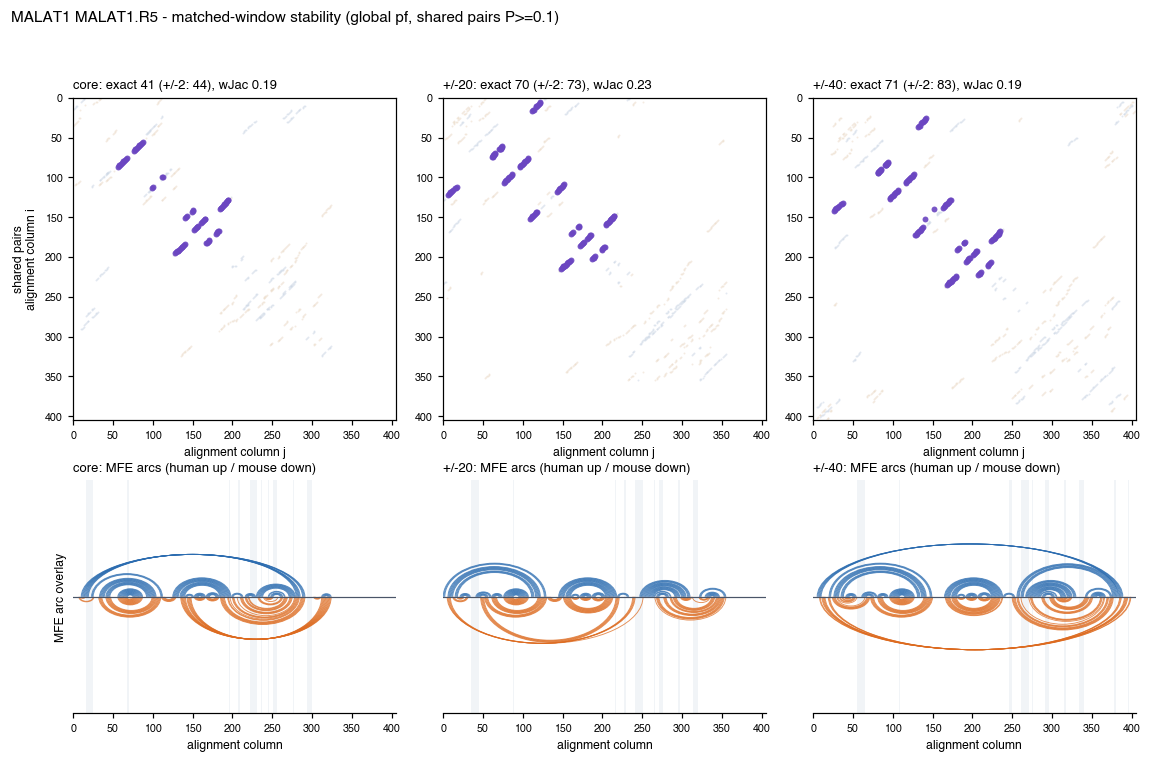

saved: malat1_MALAT1_R5_windowStability.png / .pdf


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


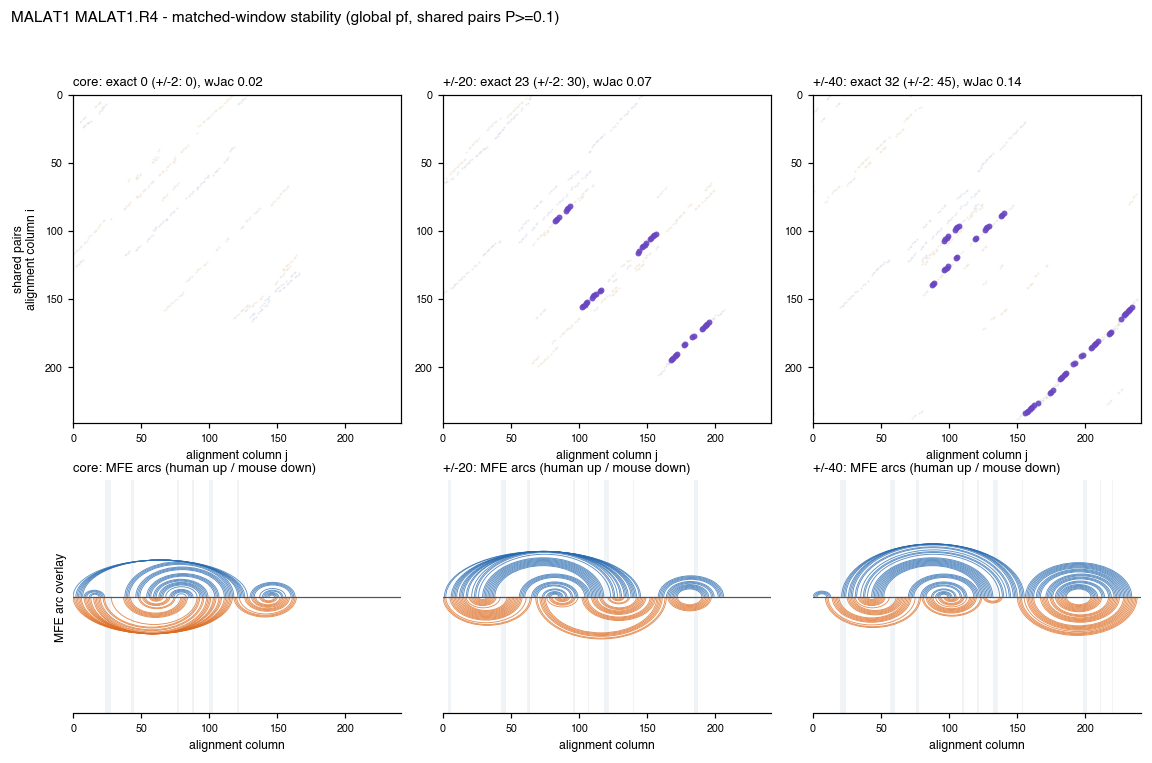

saved: malat1_MALAT1_R4_windowStability.png / .pdf


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


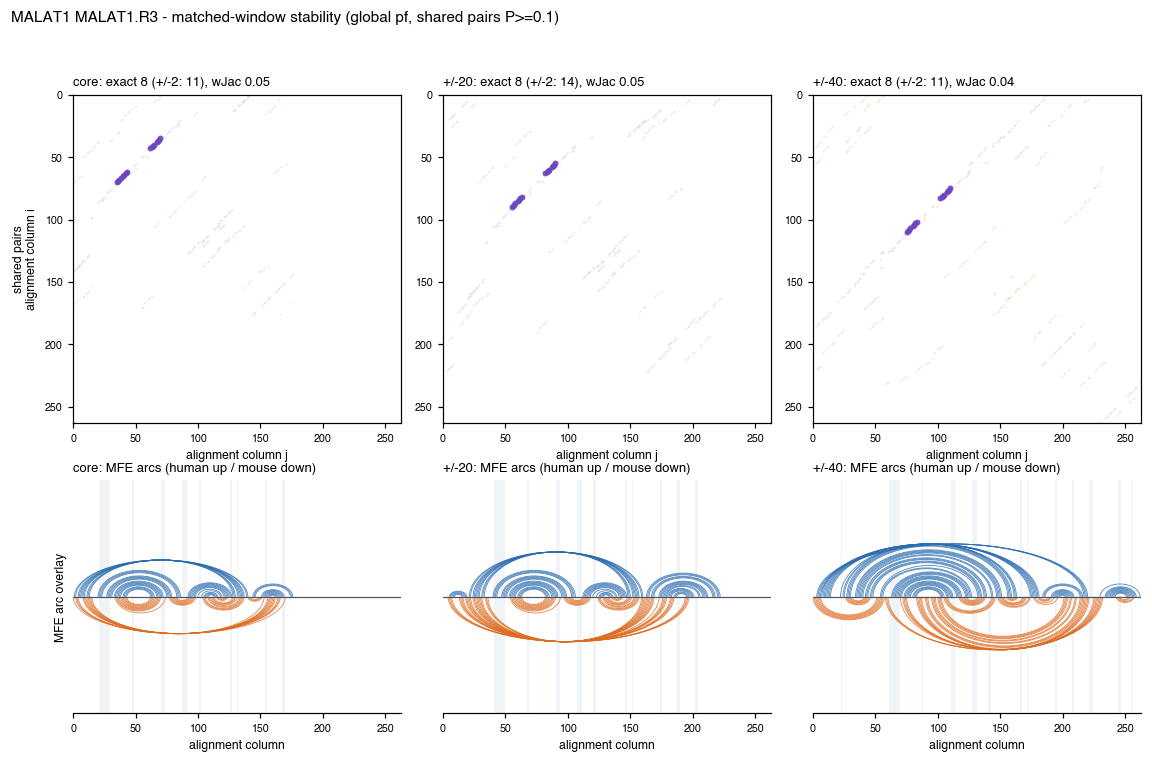

saved: malat1_MALAT1_R3_windowStability.png / .pdf


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


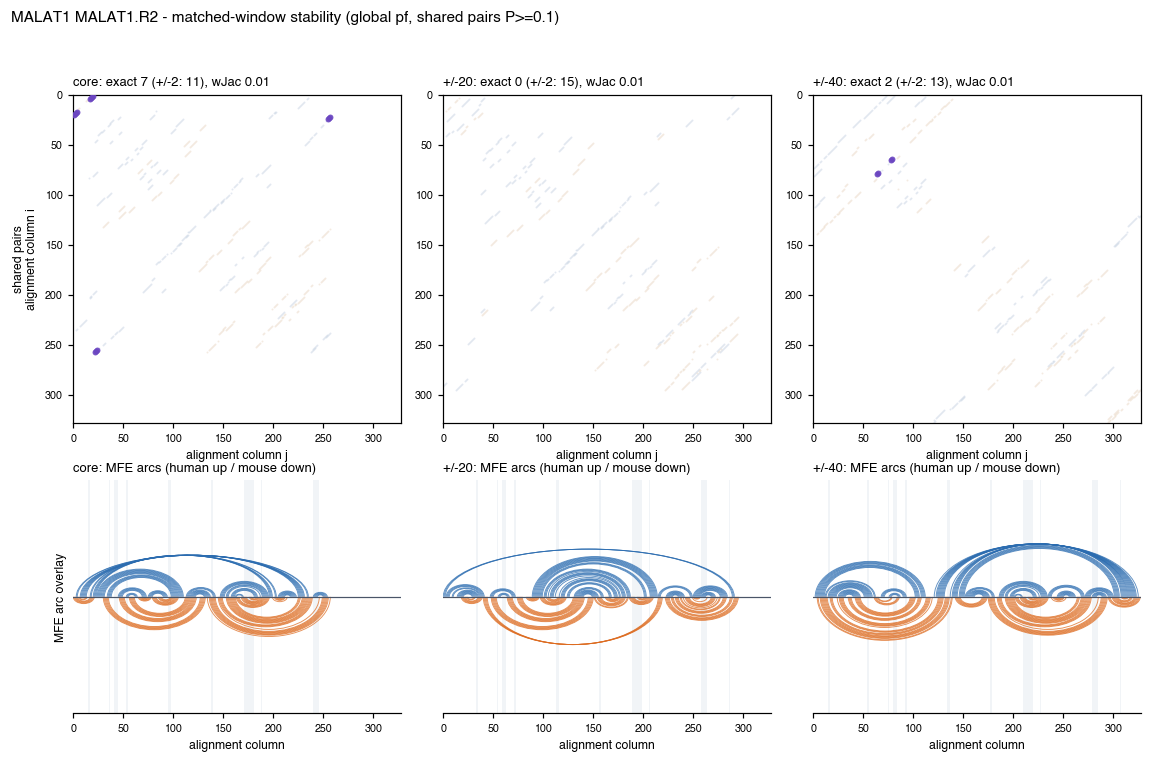

saved: malat1_MALAT1_R2_windowStability.png / .pdf


In [7]:
# --- simplified per-core window-stability: shared-pair dots + arc overlay (global pf) ---
importlib.reload(vh)
for label in MAL_LABELS:
    levels = []
    for lvname, _ in LEVELS:
        w = WIN[label][lvname]
        levels.append(dict(name=lvname, Mr=w["Mr_g"], Mq=w["Mq_g"], L=w["aln"]["L"],
                           fr=w["fr"], fq=w["fq"], aln=w["aln"], metrics=w["mg"]))
    stem = PLOTS / ("malat1_" + label.replace(".", "_") + "_windowStability")
    fig = vh.plot_window_stability(label, levels, stem, pmin=PMIN)
    display(fig)
    plt.close(fig)
    print("saved:", stem.name + ".png / .pdf")

In [8]:
# --- verdict per core + combined summary (column-exact gate; tolerant reported) ---
def _ser(label, method, col):
    s = malat_windows[(malat_windows.label == label) & (malat_windows.method == method)]
    return s.set_index("level")[col]

ASSESS = {  # manuscript-style wording (item 4)
    "MALAT1.R5": "moderate agreement, reproducible across boundary choices and global/local folding",
    "MALAT1.R4": "weak and boundary-dependent agreement (global vs local folding disagree)",
    "MALAT1.R3": "weak, inconsistent agreement",
    "MALAT1.R2": "weak agreement, near background",
}
verdicts = []
for label in MAL_LABELS:
    ge, pe = _ser(label, "global", "weighted_jaccard"), _ser(label, "plfold", "weighted_jaccard")
    gt2, pt2 = _ser(label, "global", "wov_tol2"), _ser(label, "plfold", "wov_tol2")
    verdicts.append(dict(label=label,
                         exact_wjac_core=round(ge.get("core", float("nan")), 3),
                         exact_wjac_min=round(ge.min(), 3), exact_wjac_max=round(ge.max(), 3),
                         plfold_exact_wjac_min=round(pe.min(), 3), plfold_exact_wjac_max=round(pe.max(), 3),
                         tol2_wov_core=round(gt2.get("core", float("nan")), 3),
                         tol2_wov_global_min=round(gt2.min(), 3), tol2_wov_global_max=round(gt2.max(), 3),
                         tol2_wov_plfold_min=round(pt2.min(), 3), tol2_wov_plfold_max=round(pt2.max(), 3),
                         boundary_swing=round(max(ge.max() - ge.min(), pe.max() - pe.min()), 3),
                         assessment=ASSESS[label]))
verdict_df = pd.DataFrame(verdicts)

# core-only comparable-window rows for the MAIN summary (replaces invalid full-interval rows)
mal_summary_rows = []
for label in MAL_LABELS:
    w = WIN[label]["core"]; fr, fq, aln, mg = w["fr"], w["fq"], w["aln"], w["mg"]
    ex = FOLDS[label]["extra"]
    mal_summary_rows.append(dict(
        group="malat1_core (core window)", label=label, human_gene="MALAT1",
        ref_len=fr["length"], query_len=fq["length"],
        seq_identity_table=ex.get("table_identity"), sw_norm_table=ex.get("table_sw_norm"),
        sw_aligned_ident_table=ex.get("table_sw_aligned"), curia_aligned_len=ex.get("aligned_len"),
        mmd_or_diagmmd=ex.get("table_mmd"), embedding_sw=ex.get("emb_sw"),
        ref_mfe=round(fr["mfe"], 2), query_mfe=round(fq["mfe"], 2),
        ref_ens_div=round(fr["ensemble_diversity"], 2), query_ens_div=round(fq["ensemble_diversity"], 2),
        aln_cols=aln["aln_cols"], aln_pct_id=round(aln["aln_ident"] * 100, 1),
        n_shared_exact=mg["n_shared"], weighted_jaccard=round(mg["weighted_jaccard"], 3),
        weighted_overlap=round(mg["weighted_overlap"], 3),
        n_shared_tol2=mg["n_shared_tol2"], wov_tol2=round(mg["wov_tol2"], 3),
        n_shared_tol3=mg["n_shared_tol3"], wov_tol3=round(mg["wov_tol3"], 3)))
summary = pd.concat([summary_fig5, pd.DataFrame(mal_summary_rows)], ignore_index=True)
print("per-core MALAT1 boundary-stability assessment:")
verdict_df[["label", "exact_wjac_core", "exact_wjac_min", "exact_wjac_max", "tol2_wov_core",
            "tol2_wov_global_min", "tol2_wov_global_max", "assessment"]]

per-core MALAT1 boundary-stability assessment:


,label,exact_wjac_core,exact_wjac_min,exact_wjac_max,tol2_wov_core,tol2_wov_global_min,tol2_wov_global_max,assessment
0,MALAT1.R5,0.187,0.187,0.231,0.373,0.373,0.457,"moderate agreement, reproducible across bounda..."
1,MALAT1.R4,0.016,0.016,0.137,0.000,0.000,0.325,weak and boundary-dependent agreement (global ...
2,MALAT1.R3,0.053,0.045,0.053,0.153,0.114,0.153,"weak, inconsistent agreement"
3,MALAT1.R2,0.012,0.005,0.012,0.038,0.038,0.048,"weak agreement, near background"


## Write outputs

All generated tables go under \`analysis/vienna_structure_examples/\`. Figures are already saved under \`plots/\` (PNG @300dpi + vector PDF).

In [9]:
# --- persist tables ---
summary.to_csv(OUT / "summary.tsv", sep="\t", index=False)
malat_windows.to_csv(OUT / "malat1_windows.tsv", sep="\t", index=False)
verdict_df.to_csv(OUT / "malat1_window_verdicts.tsv", sep="\t", index=False)

# exact folded sequences + MFE structures (Fig-5 pairs + every MALAT1 matched window)
seq_rows = []
for label in ["SNORD57.7", "RNU6-7.1", "VTRNA(vaultRNA).57"]:
    d = FOLDS[label]
    for which, fx in (("ref", d["fr"]), ("query", d["fq"])):
        seq_rows.append(dict(label=label, window="full", which=which, length=fx["length"],
                             mfe=round(fx["mfe"], 2), mfe_struct=fx["mfe_struct"], seq=fx["seq"]))
for label in MAL_LABELS:
    for lvname, _ in LEVELS:
        w = WIN[label][lvname]
        for which, fx in (("ref", w["fr"]), ("query", w["fq"])):
            seq_rows.append(dict(label=label, window=lvname, which=which, length=fx["length"],
                                 mfe=round(fx["mfe"], 2), mfe_struct=fx["mfe_struct"], seq=fx["seq"]))
pd.DataFrame(seq_rows).to_csv(OUT / "folded_sequences.tsv", sep="\t", index=False)

plot_files = sorted(p.name for p in PLOTS.glob("*.png")) + sorted(p.name for p in PLOTS.glob("*.pdf"))
print("wrote:")
for f in ["summary.tsv", "malat1_windows.tsv", "malat1_window_verdicts.tsv",
          "folded_sequences.tsv", "selected_examples.tsv"]:
    print("  ", (OUT / f).relative_to(REPO))
print(f"  plots/  ({len(plot_files)} files: {len(plot_files)//2} PNG + {len(plot_files)//2} PDF)")

wrote:
   analysis/vienna_structure_examples/summary.tsv
   analysis/vienna_structure_examples/malat1_windows.tsv
   analysis/vienna_structure_examples/malat1_window_verdicts.tsv
   analysis/vienna_structure_examples/folded_sequences.tsv
   analysis/vienna_structure_examples/selected_examples.tsv
  plots/  (22 files: 11 PNG + 11 PDF)


In [10]:
# --- write README.md describing methods / versions / sources / metrics / caveats ---
readme = [
    "# Exploratory ViennaRNA folding of human-mouse CURIA pairs",
    "",
    "Generated by `analysis/vienna_structure_examples.ipynb`. **Exploratory only** - not part of the manuscript or the production pipeline.",
    "",
    f"**Versions:** ViennaRNA (RNA) {RNA.__version__} - scipy {scipy.__version__} - numpy {np.__version__} - pandas {pd.__version__} - matplotlib {matplotlib.__version__} - pyrion {getattr(pyrion, '__version__', '?')} - python {sys.version.split()[0]}",
    "",
    "## What this is",
    "Explicit RNA secondary-structure folds for two groups of human->mouse CURIA pairs: (1) the three Figure-5 short ncRNAs (SNORD57, RNU6-7, vault RNA); (2) four MALAT1 recurrent cores. Structures are compared in sequence-alignment coordinates (affine-gap Smith-Waterman) so a few-nt indel does not misregister the matrices.",
    "",
    "## Sequence sources",
    "- Reference (human, hg38): `pyrion.TwoBitAccessor` on `input_data/2bit/hg38.2bit`.",
    "- Query (mouse, mm39): `modules.utils.twobit_alias.AliasedTwoBitAccessor` on `input_data/2bit/mm39.2bit`.",
    "- Intervals: Fig-5 loci from `analysis/embedding_vs_sequence/case_studies_fig5.tsv`; MALAT1 cores are the accepted island-match rows in `analysis/embedding_vs_sequence/island_pair_metrics_mouse.tsv` (gene ENSG00000251562). All coordinates are pre-registered in `selected_examples.tsv` BEFORE folding.",
    "- Strand: the human loci are '+'; mouse Malat1 is '-', so the mouse sense RNA is the reverse complement of the forward genomic fetch.",
    "",
    "## Method",
    "- Folding with ViennaRNA (default 37C Turner-2004): global partition-function BPPM, MFE, EFE, ensemble diversity, per-position pairing probability; RNAplfold local pairing (W<=150, L<=100) for MALAT1 windows.",
    "- Alignment: affine-gap Smith-Waterman local aligner (CURIA-wired `seqmetrics._sw_affine` recurrence; encoding via `pyrion.utils.encode_nucleotides`). Both BPPMs are mapped into the shared alignment coordinate system. NO 128x128 rescaling, NO flattened cosine / Frobenius.",
    "- Fig-5 short ncRNAs are similar-length and folded whole. MALAT1 cores use MATCHED WINDOWS (aligned span, +/-20, +/-40 nt; symmetric strand-preserving genomic flanks) with both global partition function and RNAplfold; the raw unequal intervals are never folded.",
    "",
    "## Metrics (all structural-overlap values EXPLORATORY, NOT validated structure-similarity scores)",
    "- CURIA nucleotide metrics carried through, labelled separately from the embedding metric: aligned nucleotide identity, normalized nucleotide-SW (nt-SW); plus nucleotide identity (edit), SW-aligned length.",
    "- Pipeline matching distance: short-branch MMD (short ncRNAs) vs island-branch embedding-SW distance (RiNALMo diag_mmd, MALAT1) - reported separately.",
    "- Structural overlap: column-exact weighted Jaccard; and tolerance-aware weighted overlap via one-to-one maximum-weight matching (weight = min(P_human,P_mouse)) when |i-k|<=tol and |j-l|<=tol, for tol=2 and tol=3 columns.",
    "",
    "## Outputs",
    "- `selected_examples.tsv` - pre-registered selection, coordinates, reasons.",
    "- `summary.tsv` - per-pair fold + column-exact + tolerant(+/-2,+/-3) overlap (Fig-5 = full interval; MALAT1 = core matched window).",
    "- `malat1_windows.tsv` - MALAT1 cores x {core, +/-20, +/-40} x {global, RNAplfold}: window lengths, coverage, column-exact + tolerant overlap.",
    "- `malat1_window_verdicts.tsv` - per-core boundary-stability assessment (column-exact + tolerant ranges across windows/methods).",
    "- `folded_sequences.tsv` - exact folded sequences + MFE dot-bracket structures (Fig-5 pairs + every MALAT1 window).",
    "- `plots/` - DIAGNOSTICS: Fig-5 comparison figures; MALAT1 core-window comparison figures; MALAT1 window-stability dot galleries (PNG @300dpi + vector PDF).",
    "- `../../paper/supplementary/vienna_structure_supplementary.pdf` - MANUSCRIPT-FACING: intro note + 3 short-ncRNA figures (S1-S3) + 4 MALAT1 core figures (S4-S7) + MALAT1 boundary-stability table (Table S1). Window-stability galleries are NOT included (diagnostics only). Standalone; not wired into the manuscript.",
    "- `vienna_helpers.py` - folding / alignment / BPPM-mapping / RNAplfold / overlap / plotting helpers.",
    "",
    "## Caveats",
    "- Exploratory only. The overlap values do NOT validate CURIA, RNA function, or evolutionary orthology.",
    "- MALAT1 overlap is only trustworthy on comparable windows; the earlier full-interval MALAT1 numbers were confounded by length asymmetry and are not used.",
    "- Column-exact matching is brittle to a 1-column register shift; the tolerant metrics quantify near-register agreement but do not establish conservation.",
    "- Examples were pre-registered before any fold was computed; no post-hoc cherry-picking.",
]
(OUT / "README.md").write_text("\n".join(readme) + "\n")
print("wrote", (OUT / "README.md").relative_to(REPO), f"({len(readme)} lines)")

wrote analysis/vienna_structure_examples/README.md (40 lines)


## Supplementary-figure PDF (manuscript-facing)

Assemble the manuscript-facing PDF: an introductory note, the three short-ncRNA case-study figures (S1-S3), the four MALAT1 core figures (S4-S7), and one compact MALAT1 boundary-stability table (Table S1). Figure headers and captions carry the carried-through CURIA nucleotide metrics (aligned identity, normalized nt-SW), the branch distance (short-branch MMD / island-branch embedding-SW distance, labelled separately), and the alignment-aware column-exact weighted Jaccard + +/-2-column tolerant weighted overlap. Written to **`paper/supplementary/vienna_structure_supplementary.pdf`**. The window-stability dot galleries are excluded from the PDF and kept as diagnostics under `analysis/vienna_structure_examples/plots/`.

In [12]:
# --- build the manuscript-facing supplementary PDF -> paper/supplementary/ ---
# Text-only revision: title / intro / captions / Table S1 wording. Folds, alignments,
# numerical values, figure order, selected examples and windows are unchanged.
from matplotlib.backends.backend_pdf import PdfPages
importlib.reload(vh)

fig5_by = summary_fig5.set_index("label")
vd = verdict_df.set_index("label")
core_g = malat_windows[(malat_windows.method == "global") & (malat_windows.level == "core")].set_index("label")
DISCLAIM = "Exploratory structural-overlap metric; see the introductory note for definitions and caveats."

def _f5cap(k, label, interp):
    r = fig5_by.loc[label]
    return (f"Figure S{k}. {label} (human vs mouse), full predicted interval; alignment-aware comparison of "
            f"ViennaRNA-predicted pairing (aligned base-pair-probability matrices, overlay contact map at P>=0.1, "
            f"per-position pairing probability, mirrored MFE arc diagrams). Sequence metrics (CURIA baseline): nucleotide "
            f"identity {r.sw_aligned_ident_table:.2f}, normalized nucleotide-SW {r.sw_norm_table:.2f}; short-branch MMD "
            f"{r.mmd_or_diagmmd:.3f} (embedding-SW distance not applicable to the short-ncRNA branch). Exploratory structural "
            f"overlap: exact weighted Jaccard {r.weighted_jaccard:.2f}, +/-2-column tolerant weighted overlap {r.wov_tol2:.2f}. "
            f"{interp} {DISCLAIM}")

def _malcap(k, label, interp):
    r = core_g.loc[label]; v = vd.loc[label]; ex = FOLDS[label]["extra"]; core = label.split(".")[-1]
    return (f"Figure S{k}. MALAT1 core {core} matched window (human {int(r.ref_len)} nt vs mouse {int(r.query_len)} nt; "
            f"alignment coverage {r.cov_ref:.2f}/{r.cov_query:.2f}) - the length-matched homologous window, not the raw "
            f"unequal island intervals. Sequence metrics (CURIA baseline): nucleotide identity {ex['table_sw_aligned']:.2f}, "
            f"normalized nucleotide-SW {ex['table_sw_norm']:.2f}; island embedding-SW distance {ex['table_mmd']:.3f} (MMD is the "
            f"short-branch term and is not used here). Exploratory structural overlap: exact weighted Jaccard "
            f"{r.weighted_jaccard:.2f} (range across core/+-20/+-40 nt {v.exact_wjac_min:.2f}-{v.exact_wjac_max:.2f}); +/-2-column "
            f"tolerant weighted overlap {r.wov_tol2:.2f}. {interp} {DISCLAIM}")

f5_interp = {
    "RNU6-7.1": "Near-identical ViennaRNA-predicted pairing after alignment-aware mapping; included as a positive control.",
    "SNORD57.7": "Partial predicted structural agreement.",
    "VTRNA(vaultRNA).57": "Both ViennaRNA-predicted folds contain prominent long-range pairing, but alignment-aware contact correspondence remains weak even after allowing small register shifts.",
}
mal_interp = {
    "MALAT1.R5": "This core showed the strongest and most stable moderate predicted structural agreement across the tested boundary windows, and was consistent across the tested folding procedures in the source data (malat1_windows.tsv).",
    "MALAT1.R4": "Weak and boundary-dependent predicted agreement; global and local folding results differ.",
    "MALAT1.R3": "Weak predicted agreement, inconsistent between global and local folding.",
    "MALAT1.R2": "Weak predicted agreement, consistently near zero across the tested windows.",
}

# compact MALAT1 boundary-stability summary table (reader-facing columns)
tbl_cols = ["Core", "Nucleotide identity", "Normalized nt-SW", "Embedding-SW distance",
            "Exact structural wJaccard (core; range)", "+/-2 tolerant structural overlap (core; range)", "Assessment"]
TBL_ASSESS = {
    "MALAT1.R5": "moderate; boundary-stable",
    "MALAT1.R4": "weak; boundary-dependent",
    "MALAT1.R3": "weak; inconsistent",
    "MALAT1.R2": "weak; consistently near zero",
}
tbl_rows = []
for label in MAL_LABELS:
    r = core_g.loc[label]; v = vd.loc[label]; ex = FOLDS[label]["extra"]
    tbl_rows.append([
        label.replace("MALAT1.", ""),
        f"{ex['table_sw_aligned']:.2f}", f"{ex['table_sw_norm']:.2f}", f"{ex['table_mmd']:.3f}",
        f"{r.weighted_jaccard:.2f} ({v.exact_wjac_min:.2f}-{v.exact_wjac_max:.2f})",
        f"{r.wov_tol2:.2f} ({v.tol2_wov_global_min:.2f}-{v.tol2_wov_global_max:.2f})",
        TBL_ASSESS[label]])
tbl_widths = [0.05, 0.10, 0.10, 0.12, 0.21, 0.23, 0.19]
tbl_caption = ("Table S1. MALAT1 recurrent cores on length-matched windows (aligned span +/- 0/20/40 nt). Sequence metrics are the "
               "CURIA baseline nucleotide identity and normalized nucleotide-SW; the embedding-SW distance is the RiNALMo island "
               "metric (nucleotide-SW and embedding-SW are distinct and reported separately). The exploratory structural-overlap "
               "metrics (exact weighted Jaccard; +/-2-column tolerant weighted overlap) are given as the core-window value and its "
               "range across the three windows; they are descriptive measures, not validated structure-similarity scores. RNAplfold "
               "local-folding results were used as an additional boundary-sensitivity check; complete per-window and per-method values "
               "are provided in malat1_windows.tsv.")

SUPP_DIR = REPO / "paper" / "supplementary"
SUPP_DIR.mkdir(parents=True, exist_ok=True)
pdf_path = SUPP_DIR / "vienna_structure_supplementary.pdf"
k = 0
with PdfPages(pdf_path) as pdf:
    vh.render_text_page(pdf, "Supplementary Figures - ViennaRNA-predicted secondary-structure comparison of selected CURIA human-mouse pairs", [
        "This exploratory analysis is supplementary to, and is not used to support, the manuscript's primary performance claims. "
        "The examples are selected case studies, not a systematic benchmark.",
        f"Software: ViennaRNA (RNA) {RNA.__version__}, pyrion {getattr(pyrion,'__version__','?')}, python {sys.version.split()[0]}.",
        "Human and mouse sequences (the exact Figure-5 short-ncRNA intervals and the accepted MALAT1 island matches) are folded with "
        "ViennaRNA and their predicted base-pair-probability matrices are compared in sequence-alignment coordinates (affine-gap "
        "Smith-Waterman), so small insertions/deletions do not misregister the two matrices.",
        "Short ncRNAs are similar-length and folded whole. MALAT1 cores are folded on length-matched windows around the aligned span "
        "(core, +-20 nt, +-40 nt) with both the global partition function and local RNAplfold; the raw, highly unequal island intervals are not folded.",
        "Sequence metrics shown in the figures (nucleotide identity, normalized nucleotide-SW) are the CURIA baseline-table values, so "
        "the supplement stays consistent with the manuscript; they are labelled separately from the embedding metric. The pipeline "
        "matching distance is the short-branch MMD for the short ncRNAs and the island embedding-SW distance (RiNALMo, diag_mmd) for "
        "MALAT1. A separate local-alignment identity computed on the analysis window is retained only in summary.tsv, not shown in the figures.",
    ])
    vh.render_text_page(pdf, "Supplementary methods - structural-overlap metrics, limitation, and contents", [
        "Structural-overlap metrics (all exploratory; not validated structure-similarity scores). Both are computed on the "
        "alignment-mapped base-pair-probability matrices P_human and P_mouse. Exact structural weighted Jaccard = "
        "sum over aligned column pairs of min(P_human(i,j), P_mouse(i,j)) / sum of max(P_human(i,j), P_mouse(i,j)).",
        "+/-2-column tolerant weighted overlap. Candidate matches are the high-probability predicted pairs (P>=0.1) in each matrix. "
        "A human pair (i,j) and a mouse pair (k,l) are compatible when BOTH aligned endpoints differ by at most two alignment columns "
        "(|i-k|<=2 and |j-l|<=2). Compatible pairs are matched ONE-TO-ONE by maximum-weight bipartite matching "
        "(scipy.optimize.linear_sum_assignment over the compatibility-restricted weight matrix; incompatible entries have weight 0 and "
        "are excluded from the reported matches). The weight of a matched pair is the smaller of the two base-pair probabilities, "
        "min(P_human, P_mouse). The score is the sum of matched weights normalized by the smaller of the two total high-probability "
        "masses, min(sum P_human, sum P_mouse), yielding a value in [0,1]. The metric is symmetric in the two species.",
        "Limitation. Structural comparison is conditional on the nucleotide alignment used to define shared coordinates. Weak structural "
        "overlap may therefore reflect either divergent predicted pairing or misregistration of structurally corresponding positions, "
        "especially at low sequence similarity.",
        "These structural-overlap values do not establish structural conservation, RNA function, or evolutionary orthology.",
        "Contents: S1-S3, short-ncRNA case studies (RNU6-7, SNORD57, vault RNA); S4-S7, MALAT1 recurrent cores R5/R4/R3/R2 on the core "
        "matched window; Table S1, MALAT1 boundary-stability summary. Per-window / per-method values and the window-stability diagnostic "
        "galleries are provided as source data under analysis/vienna_structure_examples/.",
    ])
    for label in ["RNU6-7.1", "SNORD57.7", "VTRNA(vaultRNA).57"]:
        k += 1; d = FOLDS[label]
        fig = vh.plot_pair_aligned(d["meta"], d["fr"], d["fq"], d["aln"], d["Mr"], d["Mq"], d["extra"],
                                   PLOTS / "_tmp_supp", pmin=PMIN, caption=_f5cap(k, label, f5_interp[label]))
        pdf.savefig(fig); plt.close(fig)
    for label in MAL_LABELS:
        k += 1; w = WIN[label]["core"]
        fig = vh.plot_pair_aligned(FOLDS[label]["meta"], w["fr"], w["fq"], w["aln"], w["Mr_g"], w["Mq_g"],
                                   FOLDS[label]["extra"], PLOTS / "_tmp_supp", pmin=PMIN,
                                   caption=_malcap(k, label, mal_interp[label]))
        pdf.savefig(fig); plt.close(fig)
    vh.render_table_page(pdf, "Table S1. MALAT1 recurrent cores - boundary stability & sequence metrics",
                         tbl_cols, tbl_rows, tbl_caption, col_widths=tbl_widths, figsize=(13.0, 8.5))
for tmp in PLOTS.glob("_tmp_supp.*"):
    tmp.unlink()
old = OUT / "vienna_structure_supplementary.pdf"
if old.exists():
    old.unlink()
print(f"wrote {pdf_path.relative_to(REPO)} ({k} figures + 2 intro pages + Table S1)")

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


wrote paper/supplementary/vienna_structure_supplementary.pdf (7 figures + 2 intro pages + Table S1)


## Interpretation

*Exploratory reading. All structural-overlap values (column-exact weighted Jaccard and tolerant +/-2 / +/-3 weighted overlap) are ad-hoc descriptive measures, not validated structure-similarity scores; none of this establishes structural conservation, RNA function, or orthology. Nucleotide-SW metrics (aligned identity, normalized nt-SW) and the embedding-SW distance are reported separately. MALAT1 is analysed on length-matched windows (coverage 0.87-1.00).*

**Short ncRNAs.**
- **RNU6-7** - near-identical ViennaRNA-predicted pairing after alignment-aware mapping (aligned nucleotide identity 1.00, normalized nt-SW 0.96; column-exact weighted Jaccard 0.94; tolerant +/-2 weighted overlap 1.00); included as a positive control.
- **SNORD57** - partial predicted structural agreement: column-exact overlap is modest (weighted Jaccard 0.10) but rises substantially once a small register shift is allowed (+/-2 tolerant weighted overlap 0.44), so several stems agree up to a few-column register wobble while the rest of the fold differs.
- **Vault RNA** - both ViennaRNA-predicted folds contain prominent long-range pairing, but alignment-aware contact correspondence remains weak even after allowing small register shifts (column-exact and +/-2 tolerant both 0.00; only 3 pairs match at +/-3, weighted overlap 0.11). We therefore do not claim shared secondary-structure architecture.

**MALAT1 recurrent cores (length-matched windows).**
- **R5** (nearest the annotated 3' structured region) - moderate predicted structural agreement that is reproducible across boundary choices (core/+-20/+-40 nt) and between global partition-function and local RNAplfold folding (column-exact weighted Jaccard 0.19-0.23 global, 0.22-0.26 RNAplfold; +/-2 tolerant weighted overlap 0.37-0.46 global, 0.48-0.54 RNAplfold).
- **R4** - weak and boundary-dependent: the global core-window fold shares no pairs even at +/-2 tolerance and gains overlap only as flanks are added, while RNAplfold reports a different, higher level (global vs local disagree).
- **R3** - weak and inconsistent between global and local folding.
- **R2** (lowest-similarity core) - weak predicted agreement, consistently near zero across all windows and tolerances.

**Boundary sensitivity.** R5 is the only core whose agreement is stable across the core/+-20/+-40 windows and consistent between the two folding methods; R4's apparent agreement is boundary- and method-dependent, and R3/R2 are consistently near zero. Adding the tolerant metric sharpened the reading (it lifted SNORD57 and reinforced R5) without strengthening the negatives (vault and R2-R4 remain weak).

**Supplementary suitability.** RNU6-7 is a clean positive control and MALAT1 R5 a cautious, exploratory example near the annotated 3' structured region; vault RNA is useful only as a caveat (arc-level resemblance without contact-level support); SNORD57 and MALAT1 R2-R4 are too partial or boundary/method-dependent to stand alone. The manuscript-facing PDF (`paper/supplementary/vienna_structure_supplementary.pdf`) therefore keeps the three short-ncRNA figures, the four MALAT1 core figures, and one MALAT1 boundary-stability table; the window-stability dot galleries remain diagnostics under `analysis/vienna_structure_examples/`.